## mnist_explore.ipynb
Download MNIST handwritten digit data and start exploring...

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import sys, os
sys.path.append(os.path.abspath(".."))
import src.NNN as MyNN
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.figsize"] = (1.5, 1.5)
#import sys
#print(sys.executable) # check correct .venv?

I0000 00:00:1776782009.719026   54716 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776782013.568157   54716 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


x_train.shape: (60000, 28, 28)     y_train.shape: (60000,)
x_test.shape : (10000, 28, 28)      y_test.shape: (10000,)
x_train.dtype: uint8     y_train.dtype: uint8


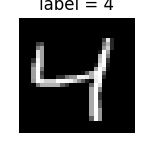

In [2]:
# load data using keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the shape of arrays
print('x_train.shape:', x_train.shape, '    y_train.shape:', y_train.shape)
print('x_test.shape :', x_test.shape, '     y_test.shape:', y_test.shape)
print('x_train.dtype:', x_train.dtype, '    y_train.dtype:', y_train.dtype)

# show one item
def draw_1_OLD(imgs, labels, index):
    plt.imshow(imgs[index], cmap="gray")
    plt.title(f"label = {labels[index]}")
    plt.axis("off")
    plt.show()
draw_1_OLD(x_train, y_train, 2)

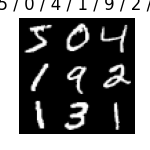

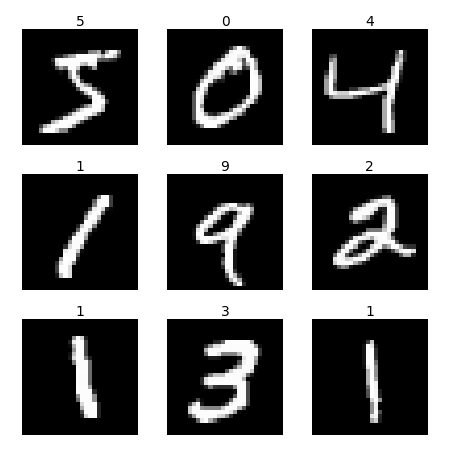

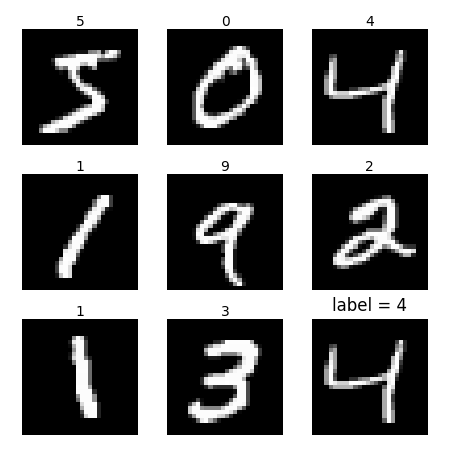

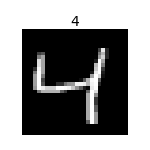

In [3]:
def draw_grid_pixels(imgs : np.ndarray, labels, i : np.ndarray, shape=None):
    pxrow, pxcol = len(imgs[0]), len(imgs[0][0])
    pixels = np.zeros((shape[0] * pxrow, shape[1] * pxcol), dtype=imgs.dtype)

    index = 0
    for r in range(shape[0]):
        for c in range(shape[1]):
            pixels[r*pxrow:(r+1)*pxrow, c*pxcol:(c+1)*pxcol] = imgs[i[index]]
            index += 1
            if index >= len(i): break

    plt.imshow(pixels, cmap="gray")
    plt.title(f"label = " + ' / '.join(str(labels[x]) for x in i))
    plt.axis("off")
    plt.show()



def draw_grid(imgs: np.ndarray, labels, indices: np.ndarray, shape: tuple[int, int]):
    rows, cols = shape
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))

    # make axes always iterable, even for 1x1
    axes = np.array(axes).reshape(rows, cols)

    index_pos = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]

            if index_pos < len(indices):
                idx = indices[index_pos]
                ax.imshow(imgs[idx], cmap="gray")
                ax.set_title(str(labels[idx]), fontsize=10, pad=2)
                index_pos += 1
            else:
                # blank unused subplot if grid is larger than number of images
                ax.axis("off")
                continue

            ax.axis("off")

    plt.tight_layout()
    plt.show()

draw_grid_pixels(x_train, y_train, np.array(list(range(9))), (3,3))
draw_grid(x_train, y_train, np.array(list(range(9))), (3,3))

def draw_1_pixels(imgs, labels, index):
    draw_grid_pixels(imgs, labels, np.array([index]), (1,1))

def draw_1(imgs, labels, index):
    draw_grid(imgs, labels, np.array([index]), (1, 1))

draw_1_pixels(x_train, y_train, 2)
draw_1(x_train, y_train, 2)

In [5]:
# use NNN.py on a real problem: MNIST digits...
# Step 1: get data ready for NN model

# convert integer data [0-255] to floats [0.0-1.0]
# one-hot encode the y labels, e.g. 5 becomes: [0000010000]
#                                               0123456789
def preprocess(x, y):
    x = x.astype(np.float32) / 255.0
    x = x.reshape(x.shape[0], -1) # keep the first dimension, unroll the rest
    y = np.eye(10)[y] # the y'th row of a 10x10 identity matrix
    return x, y

x_train_new, y_train_new = preprocess(x_train, y_train)
x_test_new, y_test_new = preprocess(x_test, y_test)
print("x_train -> x_train_new:", x_train.shape, " -> ", x_train_new.shape)
print("y_train -> y_train_new:", y_train.shape, " -> ", y_train_new.shape)

x_train -> x_train_new: (60000, 28, 28)  ->  (60000, 784)
y_train -> y_train_new: (60000,)  ->  (60000, 10)


In [7]:
# set up the layers and try running a single sample through the network
n_inputs = x_train_new.shape[1]
n_outputs = y_train_new.shape[1]

LR = [0.001, 0.01, 0.1, 0.5, 1.0]
curves_batch = []
curves_epoch = []
for lr in LR:
    model = MyNN.Model(n_inputs, [32, 32, n_outputs])

    #test_prediction = model.forward_pass(x_train_new[0])
    #print(f"Actual: {y_train[0]} --- Pred: {test_prediction}")

    # fit the model, see if the prediction improved
    y_pred = model.fit(x_train_new, y_train_new, max_epochs=5, batch_size=256, learning_rate=lr)

    curves_batch.append(model.MSE_curve_batch)
    curves_epoch.append(model.MSE_curve_epoch)


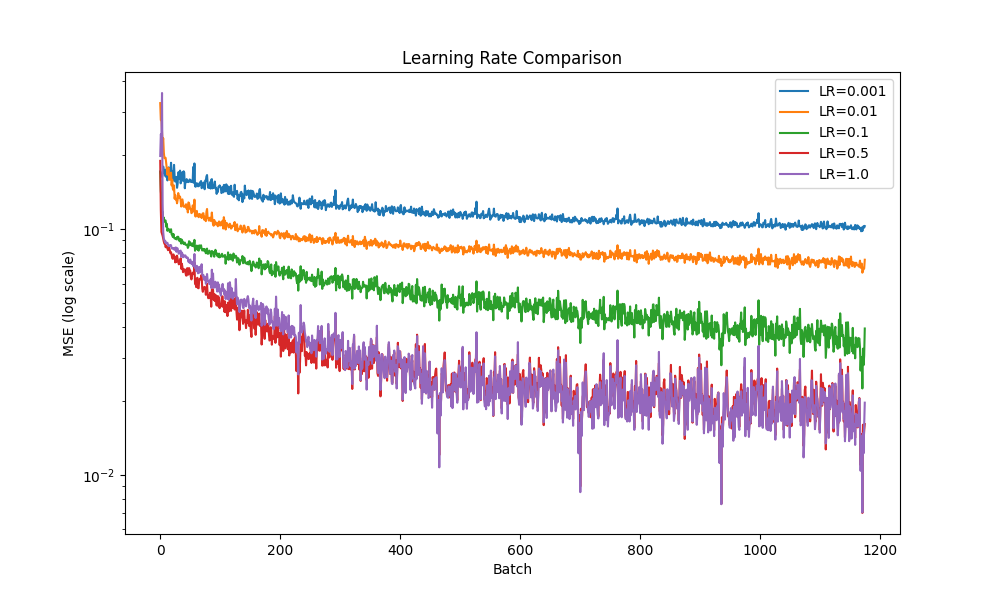

In [8]:
# Plot loss curves by batch
plt.figure(figsize=(10, 6))
for crv, lr in zip(curves_batch, LR):
    plt.plot(crv, label='LR='+str(lr))
plt.yscale('log')
plt.xlabel("Batch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

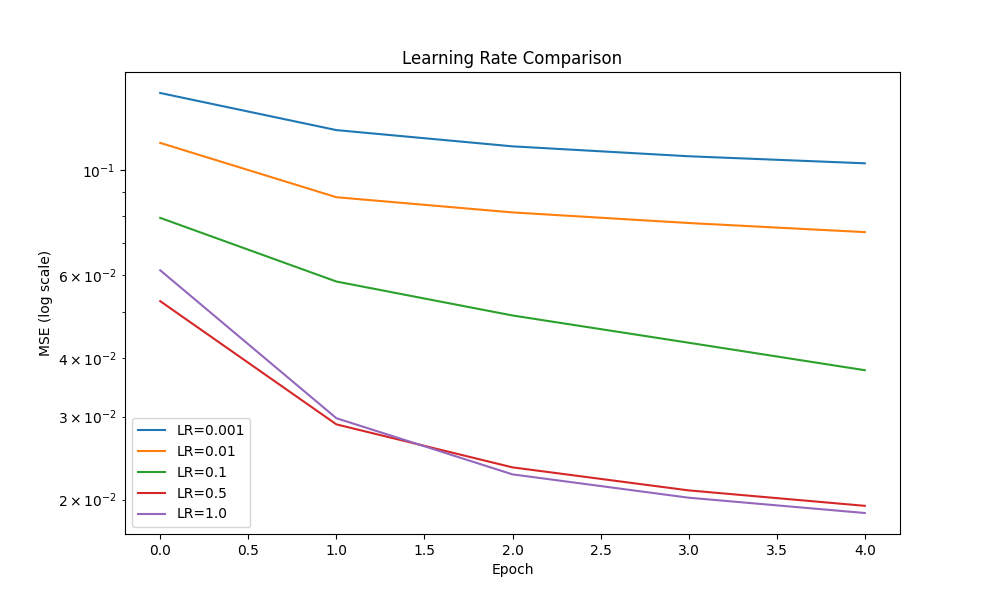

In [9]:
# Plot loss curves by epoch
plt.figure(figsize=(10, 6))
for crv, lr in zip(curves_epoch, LR):
    plt.plot(crv, label='LR='+str(lr))
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [10]:
# Calculate % accuracy of the model?
def accuracy_from_outputs(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    pred_class = np.argmax(y_pred, axis=1)
    true_class = np.argmax(y_true, axis=1)
    return np.mean(pred_class == true_class)

print( accuracy_from_outputs(y_pred, y_train_new) )

0.9013166666666667


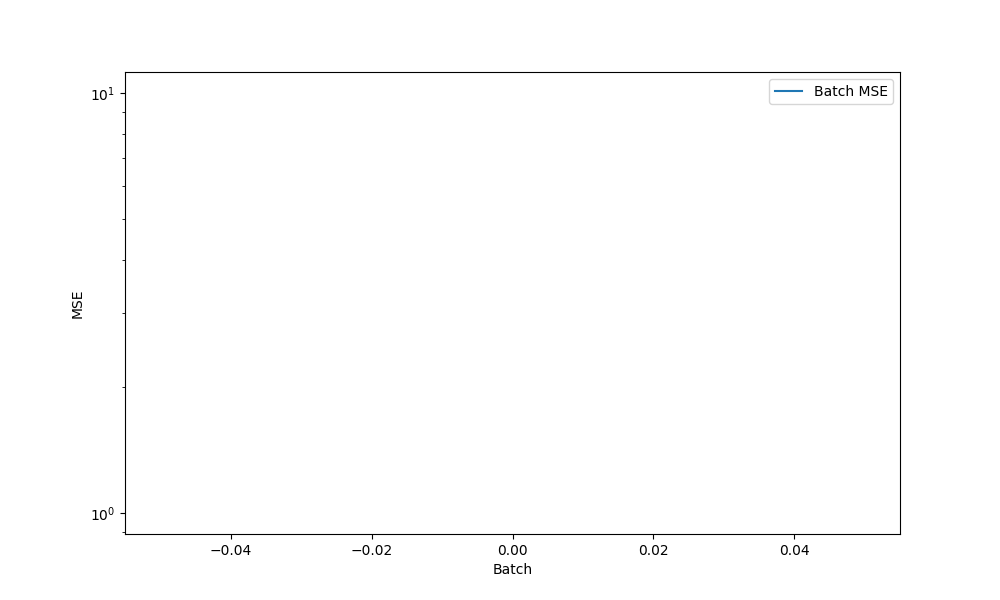

x_data[-10:]: [458, 459, 460, 461, 462, 463, 464, 465, 466, 467]
y_data[-10:]: [0.04824562947874649, 0.0465204919176238, 0.044348468064828686, 0.04285341103207933, 0.04044969434362631, 0.04068992944320703, 0.042193677718991324, 0.0328630901266677, 0.04564316753237357, 0.04069595674338542]


In [ ]:
# create live updating chart functionality via callback(s)
# supply callback function as argument to Model.fit()

#plt.ion() # turn ON interactive mode
x_data, y_data = [], []
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot([], [], label="Batch MSE")
ax.set_xlabel("Batch")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.legend()

display(fig.canvas)   # show the widget once
#plt.close(fig) # prevent duplicate static figure output later

def update_plot_loss_batch(data: dict):
    x = data["BATCH"]
    x_data.append(x)
    y_data.append(float(data['LOSS_CURVE_BATCH'][x]))

    #if x_data is None: x_data = list(range(len(y_data)))    
    line.set_data(x_data, y_data)
    ax.relim()
    ax.autoscale_view()
    
    if x % 10 == 0:
        fig.canvas.draw()
        fig.canvas.flush_events()
        plt.pause(0.001)

model_live = MyNN.Model(n_inputs, [32, 32, n_outputs])
results = model_live.fit(x_train_new, y_train_new, max_epochs=2, batch_size=256, learning_rate=0.1, callback_func=update_plot_loss_batch)

#plt.close(fig) # prevent duplicate static figure output later
#plt.ioff() # turn OFF interactive mode
#plt.show()

print("x_data[-10:]:", x_data[-10:])
print("y_data[-10:]:", y_data[-10:])